# Donnée météorologiques

In [1]:
from datetime import datetime
from plotly.graph_objects import FigureWidget
from IPython.display import display
from ipywidgets import HBox, VBox, Box, fixed, interactive_output, Output

import os
import sys
import csv
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
import plotly.graph_objects as go

sys.path.append(os.path.abspath("./"))
import helpers as _

## Import des données de 2023 de la station de Bron

In [2]:
df = pd.read_csv('Meteo/data/meteo_horaire_69_69029001_2023.csv')
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d%H')

df

,POSTE,DATE,RR1,DRR1,HNEIGEF,NEIGETOT,T,TD,TN,HTN,...,TMER,VVMER,ETATMER,DIRHOULE,TLAGON,UV2,INS2,INFRAR2,DIR2,DIF2
0,69029001,2023-01-01 00:00:00,0.0,0.0,NaN,0.0,14.9,8.0,14.7,2302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,69029001,2023-01-01 01:00:00,0.0,0.0,NaN,0.0,14.8,7.8,14.7,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,69029001,2023-01-01 02:00:00,0.0,0.0,NaN,0.0,14.9,7.0,14.7,101.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,69029001,2023-01-01 03:00:00,0.0,0.0,NaN,0.0,15.1,6.8,15.0,201.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,69029001,2023-01-01 04:00:00,0.0,0.0,NaN,0.0,15.1,7.1,15.0,329.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,69029001,2023-12-31 19:00:00,0.0,0.0,NaN,0.0,5.9,3.8,5.9,1854.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
8756,69029001,2023-12-31 20:00:00,0.0,0.0,NaN,0.0,5.0,3.0,4.8,1950.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
8757,69029001,2023-12-31 21:00:00,0.0,0.0,NaN,0.0,4.4,2.7,4.4,2057.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
8758,69029001,2023-12-31 22:00:00,0.0,0.0,NaN,0.0,4.4,2.9,4.3,2106.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


## Visualisation de la qualité des données

In [3]:
df_sorted = df[sorted(df.columns)]
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 99 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         8738 non-null   float64       
 1   B2         3000 non-null   float64       
 2   B3         1320 non-null   float64       
 3   B4         0 non-null      float64       
 4   C1         0 non-null      float64       
 5   C2         0 non-null      float64       
 6   C3         0 non-null      float64       
 7   C4         0 non-null      float64       
 8   CH         0 non-null      float64       
 9   CL         0 non-null      float64       
 10  CM         0 non-null      float64       
 11  DATE       8760 non-null   datetime64[ns]
 12  DD         8720 non-null   float64       
 13  DD2        0 non-null      float64       
 14  DG         8759 non-null   float64       
 15  DHUMEC     0 non-null      float64       
 16  DHUMI40    8757 non-null   float64       


## Selections des données intéressantes

- T           : température sous abri instantanée (en °C)
- PSTAT       : pression station (en hPa)
- PMER        : pression mer (en hPa)
- TSV         : tension de vapeur (en hPa)
- RR1         : quantité de précipitation (en mm)
- DRR1        : durée des précipitations (en mn)
- U           : humidité relative (en %)
- FF          : force du vent moyenné sur 10 mn
- N           : nébulosité totale (en octa)
- SOL         : état du sol sans neige 

In [6]:
columns = ['DATE', 'T', 'PSTAT', 'PMER', 'TSV', 'RR1', 'DRR1', 'U', 'FF', 'N', 'SOL']
df_filtered = df[columns]

df_grouped = df_filtered.set_index('DATE').resample('D').median().reset_index()

display(
    _.generate_box([
        _.generate_widget_table(df_filtered), 
        _.generate_widget_table(df_grouped)
    ])
)

Box(children=(Output(), Output()), layout=Layout(align_items='center', display='flex', flex_flow='row wrap', j…

## Recherche de corrélations

In [8]:
display(
    _.generate_box(
        children=[
            _.generate_widget_corr(df_filtered, title='By hour', width=950, height=1000),
            _.generate_widget_corr(df_grouped, title='By day', width=950, height=1000)
        ]
    )
)

Box(children=(FigureWidget({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<b…

In [15]:
df_f_simple = df_filtered.sample(frac=0.01)
df_g_simple = df_grouped.sample(frac=0.2)

display(
    _.generate_box([
        _.generate_widget_scatter_matrix(df_f_simple, title='By hour', width=950, height=1600),
        _.generate_widget_scatter_matrix(df_g_simple, title='By day', width=950, height=1600)
    ]),
)

Box(children=(FigureWidget({
    'data': [{'dimensions': [{'axis': {'matches': True},
                        …

## Selections de colonnes potentielles

In [18]:
columns_selection = ['DATE', 'PSTAT', 'PMER', 'T', 'TSV', 'U', 'FF']

display(
    _.generate_box([
        _.generate_widget_scatter_matrix(df_f_simple, columns=columns_selection, title='By hour', width=950, height=1200),
        _.generate_widget_scatter_matrix(df_g_simple, columns=columns_selection, title='By day', width=950, height=1200),
    ])
)

Box(children=(FigureWidget({
    'data': [{'dimensions': [{'axis': {'matches': True},
                        …

## Rappels

R2 = 1 :
- Le modèle explique 100 % de la variance de la variable dépendante.
- Toutes les prédictions correspondent parfaitement aux valeurs observées.

R2 = 0 :
- Le modèle n'explique aucune variance de la variable dépendante.
- Cela signifie que le modèle n'apporte aucune amélioration par rapport à un modèle trivial qui prédirait simplement la moyenne de la variable dépendante.

0 < R2 < 1 :
- Le modèle explique une certaine proportion de la variance (par exemple, R2=0.75 signifie que 75 % de la variance est expliquée).

R2 < 0 :
- Cela peut arriver si le modèle est mal ajusté ou si vous utilisez une régression non linéaire. Cela signifie que le modèle est pire que de simplement prédire la moyenne.

## Création d'un modèle

On s'attend à avoir environ 16.44° pour un TSV/U de 0.
Chaque TSV/U supplémentaire ajoute environ 1.37 T, ou on ajoute 137T tous les 100 TSV/U.

    Le coefficient de détermination, R² ~= 0.96, signifie que le modèle explique 96% de la variance.
    L'erreur moyenne quadratique MSE vaut environ 2.7. Plus la MSE est faible, meilleur est le modèle.
    L'erreur moyenne absolue MAE se situe vers 1.18, ce qui est interprétable : cela signifie qu'en moyenne, l'erreur de prédiction sera d'environ 1.18 T.
    


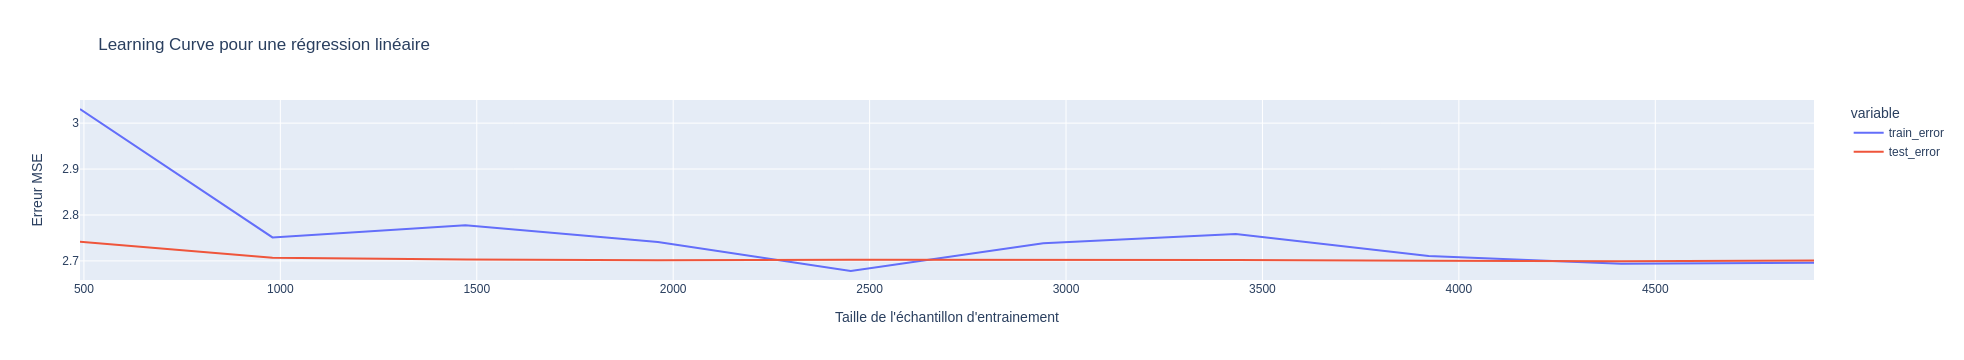

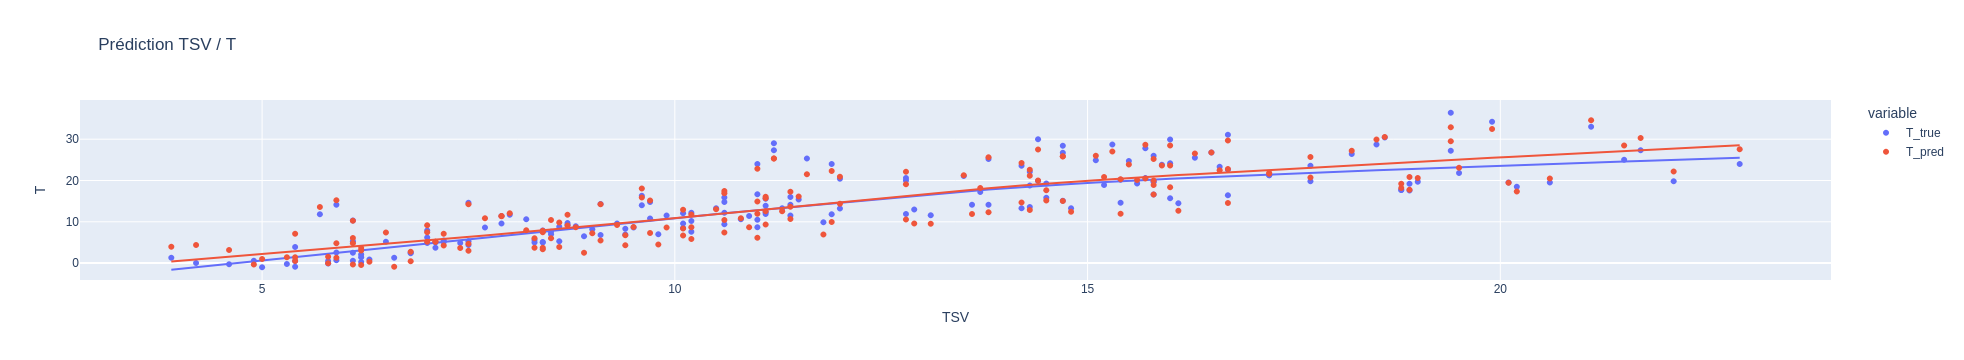

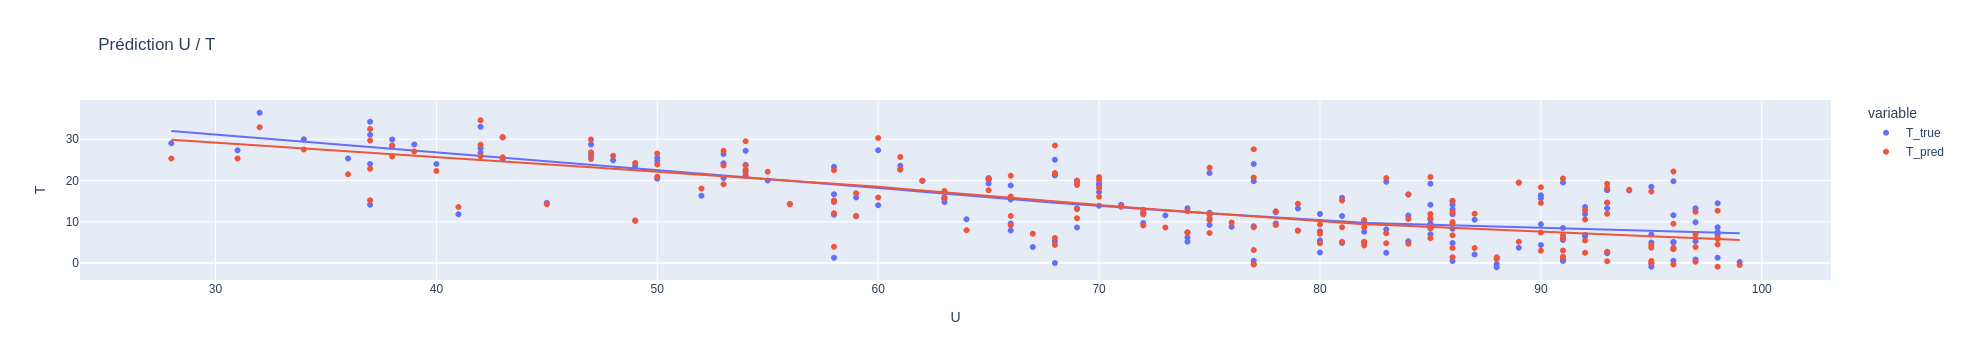


    Coefficient de détermination, R² : (à augmenter)
    - Train = 0.9634949896872882
    - Test =  0.963316567984466
    
    L'erreur moyenne quadratique MSE : (à réduire)
    - Train = 2.6963048126433513
    - Test =  2.679886363399102
    
    L'erreur moyenne absolue MAE : (à réduire)
    - Train = 1.1798731540130398
    - Test =  1.1772285436029528
    
    Un sur-apprentissage se détecte si les métriques sont trop différente
    


In [23]:
model_1, r2_train, mse_train, mae_train = _.regression_lineaire(df, ['TSV', 'U'], 'T')

## Test du modèle sur les données de 2024 à Bron

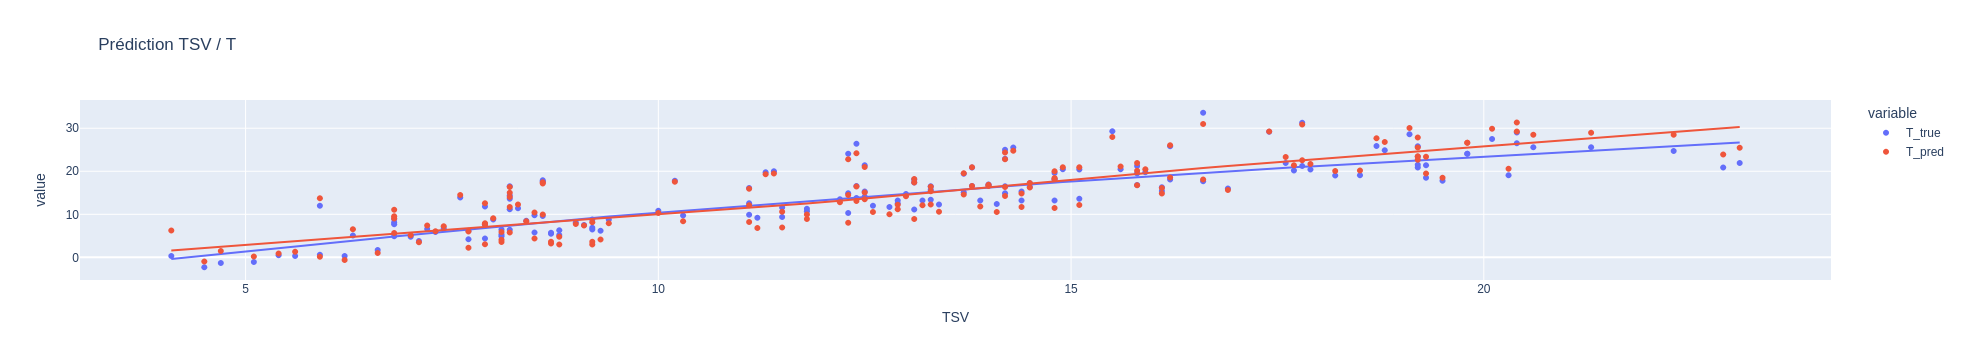

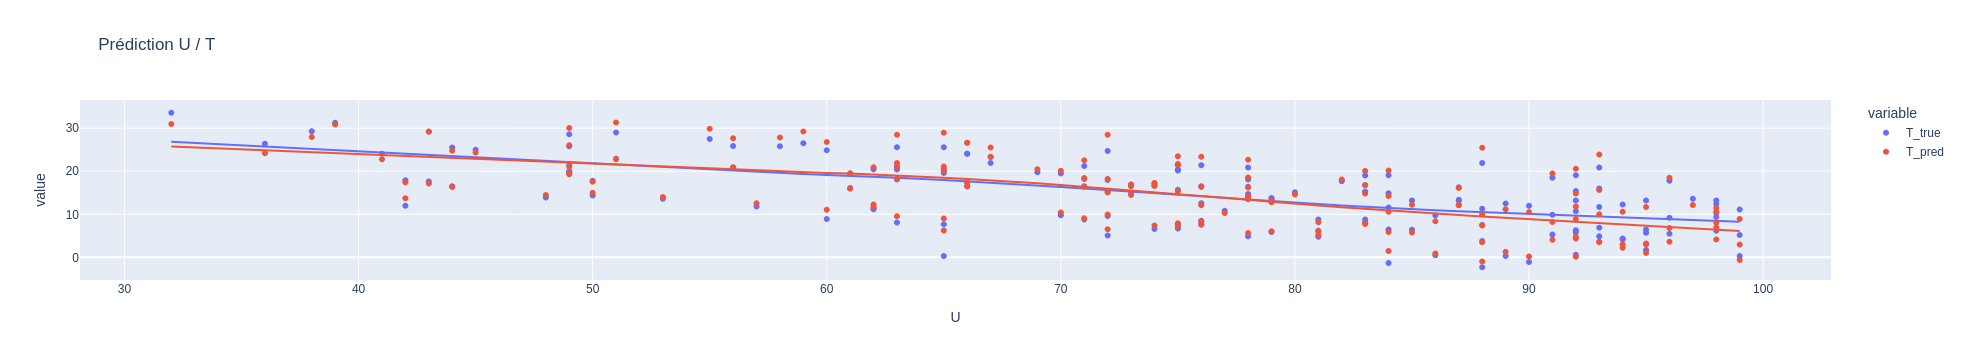


    Coefficient de détermination, R² : (à augmenter)
    - Train = 0.9634949896872882
    - Test =  0.9613735931648897
    
    L'erreur moyenne quadratique MSE : (à réduire)
    - Train = 2.6963048126433513
    - Test =  2.147353859462865
    
    L'erreur moyenne absolue MAE : (à réduire)
    - Train = 1.1798731540130398
    - Test =  1.0940004630771079
    
    Un sur-apprentissage se détecte si les métriques sont trop différente
    


(LinearRegression(),
 0.9634949896872882,
 2.6963048126433513,
 1.1798731540130398)

In [5]:
df_2024 = pd.read_csv('Meteo/data/meteo_horaire_69_69029001_2024.csv')

_.regression_lineaire_test(model_1, df_2024, ['TSV', 'U'], 'T', r2_train, mse_train, mae_train)

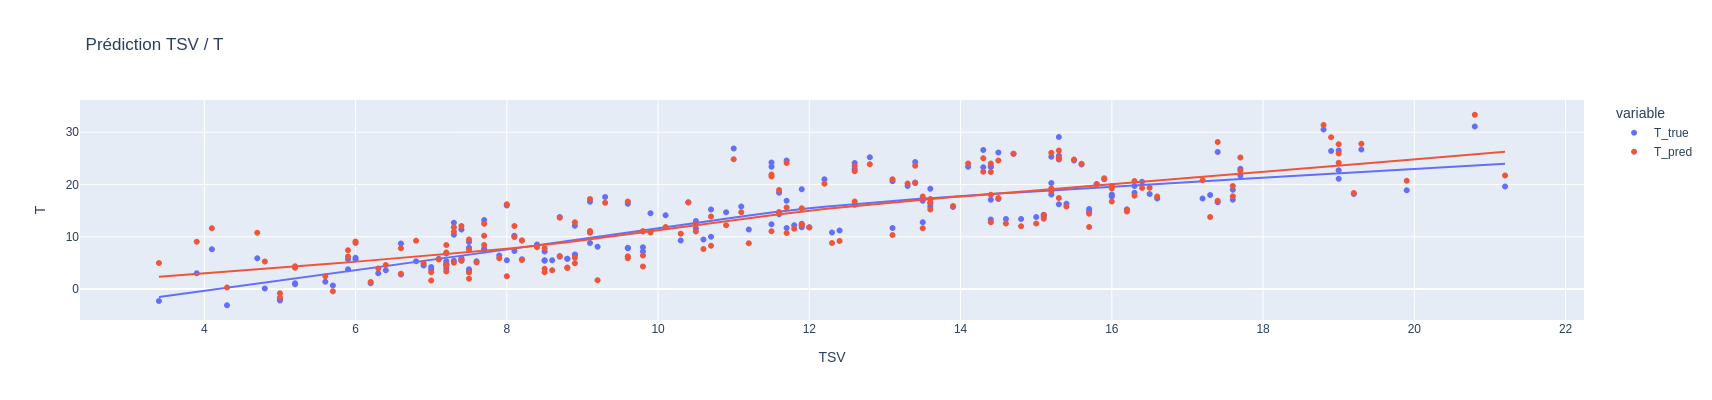

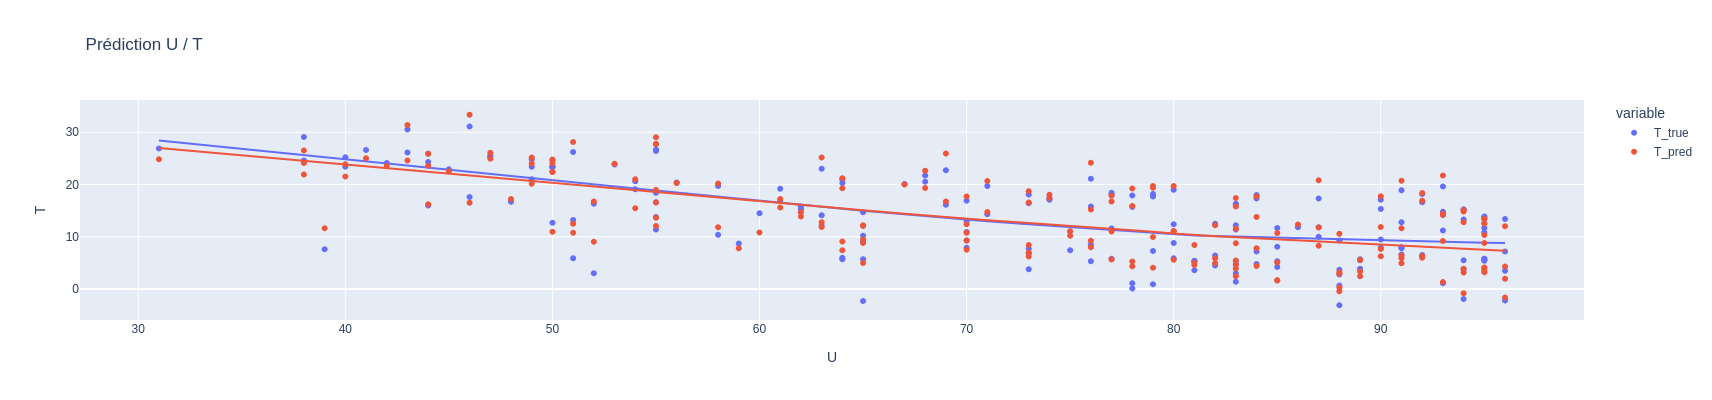


    Coefficient de détermination, R² : (à augmenter)
    - Train = 0.9634949896872882
    - Test =  0.965791918496432
    
    L'erreur moyenne quadratique MSE : (à réduire)
    - Train = 2.6963048126433513
    - Test =  1.9564272385981138
    
    L'erreur moyenne absolue MAE : (à réduire)
    - Train = 1.1798731540130398
    - Test =  0.9799637793440922
    
    Un sur-apprentissage se détecte si les métriques sont trop différente
    


(LinearRegression(),
 0.9634949896872882,
 2.6963048126433513,
 1.1798731540130398)

In [36]:
df_2000 = pd.read_csv('Meteo/data/meteo_horaire_69_69029001_2000.csv')

_.regression_lineaire_test(model_1, df_2000, ['TSV', 'U'], 'T', r2_train, mse_train, mae_train)